
Top 10 Alcaldías (Líneas 1 y 6):
                      Estación  Robos
0           Cuauhtémoc línea 6    129
1       Miguel Hidalgo línea 1     40
2  Venustiano Carranza línea 1     25
3             Coyoacán línea 1     24
4        Benito Juárez línea 1     18
5           Iztapalapa línea 6     16
6    Gustavo A. Madero línea 6     13
7         Azcapotzalco línea 1      9
8            Iztacalco línea 1      8
9                        CUH-1      7


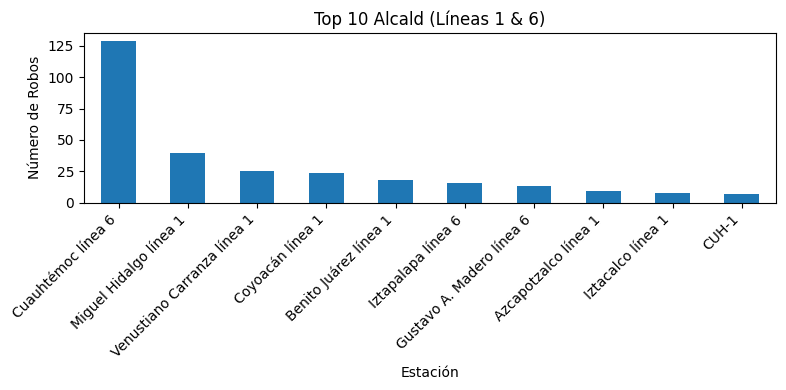


Robos por hora del día:
    Hora  Robos          Periodo
0      1      8  Madrugada (0-5)
1      2      7  Madrugada (0-5)
2      3      9  Madrugada (0-5)
3      4      9  Madrugada (0-5)
4      5     11  Madrugada (0-5)
5      6     25    Mañana (6-11)
6      7     40    Mañana (6-11)
7      8     38    Mañana (6-11)
8      9     27    Mañana (6-11)
9     10     21    Mañana (6-11)
10    11     13    Mañana (6-11)
11    12     18    Tarde (12-17)
12    13      7    Tarde (12-17)
13    14      4    Tarde (12-17)
14    15      9    Tarde (12-17)
15    16      7    Tarde (12-17)
16    17      6    Tarde (12-17)
17    18      7    Noche (18-23)
18    19     10    Noche (18-23)
19    20      6    Noche (18-23)
20    21      5    Noche (18-23)
21    22      2    Noche (18-23)
22    23      2    Noche (18-23)


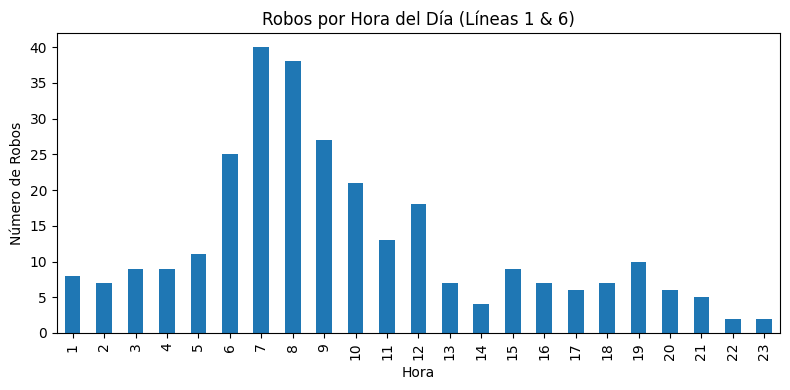


Robos por periodo del día:
           Periodo  Robos
0  Madrugada (0-5)     44
1    Mañana (6-11)    164
2    Noche (18-23)     32
3    Tarde (12-17)     51


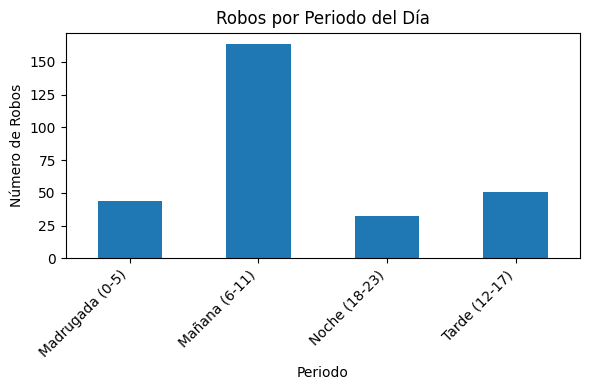


Comparativo de robos por línea:
  Línea  Robos
0     1    133
1     6    158


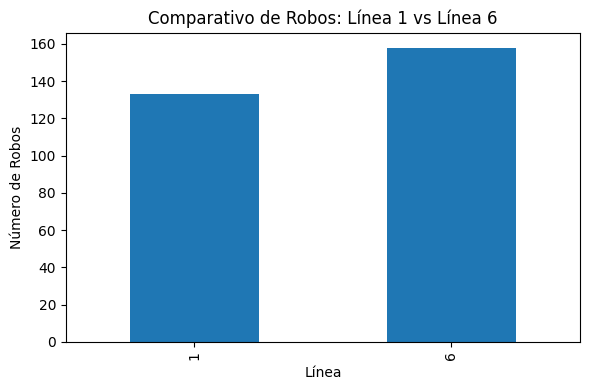

In [25]:
import pandas as pd # Manipulación de datos
import matplotlib.pyplot as plt # Graficar
from posixpath import sep # Separador en archivo semi estructurado

# -------------- Cargar datos -------------------------------------
datos = pd.read_csv('/content/1A DELITOS(2024).csv', sep=",")

# Filtrar robos en Metro
robos_metro = datos[datos['DELITO'] == 'ROBO A PASAJERO A BORDO DEL METRO CON Y SIN VIOLENCIA']
assert robos_metro.shape[0] == 1184, f"Total esperado 1184, encontrado {robos_metro.shape[0]}"

# Filtrar líneas 1 y 6
robos_lineas = robos_metro[robos_metro['CT HECHOS'].str.endswith('-1') | robos_metro['CT HECHOS'].str.endswith('-6')].copy()

# Mapeo de códigos a nombres
mapeo_alcaldias = {
    'CUH-6': 'Cuauhtémoc línea 6',
    'MH-1': 'Miguel Hidalgo línea 1',
    'VC-1': 'Venustiano Carranza línea 1',
    'COY-1': 'Coyoacán línea 1',
    'BJ-1': 'Benito Juárez línea 1',
    'IZP-6': 'Iztapalapa línea 6',
    'GAM-6': 'Gustavo A. Madero línea 6',
    'AZ-1': 'Azcapotzalco línea 1',
    'IZC-1': 'Iztacalco línea 1',
    'TLH-6': 'Tláhuac línea 6'
}

# Reemplazar etiquetas actuales por los NA
robos_lineas['EtiquetaEstacion'] = robos_lineas['CT HECHOS'].map(mapeo_alcaldias).fillna(robos_lineas['CT HECHOS'])

# Top 10 estaciones actuales
conteo_estaciones = robos_lineas['EtiquetaEstacion'].value_counts().head(10).reset_index()
conteo_estaciones.columns = ['Estación', 'Robos']

# Distribución por línea de los hechos
robos_lineas['Línea'] = robos_lineas['CT HECHOS'].str.split('-').str[1]
conteo_lineas = robos_lineas['Línea'].value_counts().sort_index().reset_index()
conteo_lineas.columns = ['Línea', 'Robos']

# Distribución horaria en cada uno de los picos por periodos
robos_lineas['Hora'] = pd.to_datetime(robos_lineas['HORA DE LOS HECHOS'], format='%H:%M').dt.hour
conteo_horas = robos_lineas['Hora'].value_counts().sort_index().reset_index()
conteo_horas.columns = ['Hora', 'Robos']

# Definir periodos actuales
def categorizar_periodo(hora):
    if 0 <= hora < 6:
        return 'Madrugada (0-5)'
    elif 6 <= hora < 12:
        return 'Mañana (6-11)'
    elif 12 <= hora < 18:
        return 'Tarde (12-17)'
    else:
        return 'Noche (18-23)'

conteo_horas['Periodo'] = conteo_horas['Hora'].apply(categorizar_periodo)
conteo_periodos = conteo_horas.groupby('Periodo')['Robos'].sum().reset_index()

# ------------------------- Gráficas ------------------------ #

# 1) Top 10 alcaldias
print("\nTop 10 Alcaldías (Líneas 1 y 6):")
print(conteo_estaciones)

plt.figure(figsize=(8,4))
conteo_estaciones.set_index('Estación')['Robos'].plot(kind='bar')
plt.title('Top 10 Alcald (Líneas 1 & 6)')
plt.xlabel('Estación')
plt.ylabel('Número de Robos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2) Robos por hora en cada uno de los puntos
print("\nRobos por hora del día:")
print(conteo_horas)

plt.figure(figsize=(8,4))
conteo_horas.set_index('Hora')['Robos'].plot(kind='bar')
plt.title('Robos por Hora del Día (Líneas 1 & 6)')
plt.xlabel('Hora')
plt.ylabel('Número de Robos')
plt.tight_layout()
plt.show()

# 3) Robos por periodo del día
print("\nRobos por periodo del día:")
print(conteo_periodos)

plt.figure(figsize=(6,4))
conteo_periodos.set_index('Periodo')['Robos'].plot(kind='bar')
plt.title('Robos por Periodo del Día')
plt.xlabel('Periodo')
plt.ylabel('Número de Robos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4) Comparativo Línea 1 vs Línea 6
print("\nComparativo de robos por línea:")
print(conteo_lineas)

plt.figure(figsize=(6,4))
conteo_lineas.set_index('Línea')['Robos'].plot(kind='bar')
plt.title('Comparativo de Robos: Línea 1 vs Línea 6')
plt.xlabel('Línea')
plt.ylabel('Número de Robos')
plt.tight_layout()
plt.show()



# Derechos reservados para Brandon Uriel Garcia Sanchez
#